# TV3 – MLP bằng PyTorch (House Prices)

**Mục tiêu:** xây dựng MLP trên dữ liệu đã xử lý của TV1, tìm đặc trưng/cấu hình tốt nhất,
rồi so sánh với kết quả của TV2 (XGBoost Tuned: Validation Log RMSE = **0.135426**, Kaggle **0.13357**).

**Quy ước của nhóm (theo README bàn giao của TV2):**
- Giữ nguyên split train/val của TV1 (1168 / 292), không chia lại.
- Metric: Log RMSE = `sqrt(MSE(log1p(y_val), log1p(max(pred, 0))))`.
- `RANDOM_STATE = 42`.

**Quy trình thực nghiệm:**
| Bước | Nội dung |
|---|---|
| A | 4 feature set của TV1 (Full / Top20 / Top40 / Top60) × 2 cách chuẩn hóa đầu vào |
| A2 | Đặc trưng nâng cao: số lượng feature tối ưu (k), bỏ feature TV1 tự tạo, loại outlier GrLivArea > 4000 (theo paper De Cock) |
| B | Tìm hyperparameter bằng 3-fold CV **chỉ trên tập train** (val không tham gia chọn cấu hình) |
| C | Đánh giá cuối trên val, so sánh TV2, tạo submission |

In [1]:
import json
import random
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import skew
from sklearn.feature_selection import mutual_info_regression
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
QUICK = False                  # True = chạy thử rất nhanh (ít epoch/seed) để kiểm tra lỗi
BASE_PATH = Path("../HousePrices_TV1/results/member1/processed")   # giống notebook của TV2
OUT_DIR = Path("results/member3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 15 if QUICK else 150
N_SEEDS = 2 if QUICK else 5          # số seed cho thí nghiệm A, A2
N_FINAL_SEEDS = 2 if QUICK else 10   # số seed cho kết quả cuối
N_CONFIGS = 3 if QUICK else 12       # số cấu hình thử ở bước B
TV2_XGB_TUNED = 0.135426
print("device:", DEVICE, "| epochs:", EPOCHS, "| quick:", QUICK)

device: cpu | epochs: 150 | quick: False


## 1. Load và kiểm tra dữ liệu (giống cách TV2 đọc)

In [2]:
SETS = ["full", "top_20", "top_40", "top_60"]
data = {
    s: {sp: pd.read_csv(BASE_PATH / f"X_{sp}_{s}.csv") for sp in ["train", "val", "test"]}
    for s in SETS
}
y_train = pd.read_csv(BASE_PATH / "y_train.csv")["SalePrice"].values.astype(float)
y_val = pd.read_csv(BASE_PATH / "y_val.csv")["SalePrice"].values.astype(float)
test_ids = pd.read_csv(BASE_PATH / "test_ids.csv")

for s in SETS:
    d = data[s]
    same_cols = list(d["train"].columns) == list(d["val"].columns) == list(d["test"].columns)
    nan_total = int(sum(d[sp].isna().sum().sum() for sp in d))
    print(f"{s:7s} train{d['train'].shape} val{d['val'].shape} test{d['test'].shape} "
          f"| cột khớp: {same_cols} | NaN: {nan_total}")
print("y_train", y_train.shape, "| y_val", y_val.shape, "| test_ids", test_ids.shape)
assert len(data["full"]["train"]) == len(y_train) and len(data["full"]["val"]) == len(y_val)

# Dữ liệu TV1 mới chỉ impute + one-hot (chưa scale) -> MLP cần chuẩn hóa. Xem thang đo:
desc = data["full"]["train"].describe().T
print("\nCột có max lớn nhất (chưa scale):")
print(desc.sort_values("max", ascending=False)[["mean", "std", "max"]].head(5).round(1))

full    train(1168, 279) val(292, 279) test(1459, 279) | cột khớp: True | NaN: 0
top_20  train(1168, 20) val(292, 20) test(1459, 20) | cột khớp: True | NaN: 0
top_40  train(1168, 40) val(292, 40) test(1459, 40) | cột khớp: True | NaN: 0
top_60  train(1168, 60) val(292, 60) test(1459, 60) | cột khớp: True | NaN: 0
y_train (1168,) | y_val (292,) | test_ids (1459, 1)

Cột có max lớn nhất (chưa scale):
                          mean      std       max
LotArea                10689.6  10759.4  215245.0
OverallQual_GrLivArea   9767.0   5171.7   56420.0
MiscVal                   51.3    553.0   15500.0
TotalSF                 2583.5    821.3   11752.0
TotalBsmtSF             1061.8    440.7    6110.0


## 2. Chuẩn hóa đầu vào riêng cho MLP (fit CHỈ trên train)

Mạng neural nhạy với thang đo nên cần chuẩn hóa; đây là bước đặc thù của MLP, không thay đổi
preprocessing/feature selection của TV1. Hai chế độ:
- `std`: StandardScaler.
- `log_std`: log1p cho các biến số lệch phải (skew > 0.75, không phải biến 0/1) rồi StandardScaler.

Giá trị sau scale được cắt về [-10, 10] để các cột one-hot hiếm không tạo giá trị cực lớn.

In [3]:
def transform_features(Xtr_df, others, mode):
    """Fit trên Xtr_df, áp dụng cho các DataFrame trong `others`. Trả về [Xtr, *others] dạng numpy."""
    Xtr = Xtr_df.values.astype(np.float64)
    outs = [o.values.astype(np.float64) for o in others]
    if mode == "log_std":
        sk = np.array([skew(Xtr[:, j]) if Xtr[:, j].std() > 0 else 0.0 for j in range(Xtr.shape[1])])
        nun = np.array([len(np.unique(Xtr[:, j])) for j in range(Xtr.shape[1])])
        cols = np.where((sk > 0.75) & (nun > 2) & (Xtr.min(axis=0) >= 0))[0]

        def f(A):
            A = A.copy()
            A[:, cols] = np.log1p(np.clip(A[:, cols], 0, None))
            return A
        Xtr, outs = f(Xtr), [f(o) for o in outs]
    elif mode != "std":
        raise ValueError(mode)
    sc = StandardScaler().fit(Xtr)
    res = [np.clip(sc.transform(A), -10, 10) for A in [Xtr] + outs]
    return res

## 3. Mô hình MLP + vòng huấn luyện

- Khối: `Linear → BatchNorm → ReLU → Dropout`, đầu ra 1 nơ-ron.
- Huấn luyện trên `log1p(SalePrice)` với MSE (khớp metric Log RMSE), bias đầu ra khởi tạo bằng trung bình log giá.
- Số epoch cố định + CosineAnnealing; điểm báo cáo là epoch **cuối** (không chọn epoch tốt nhất theo val → không lạc quan).

In [4]:
class MLP(nn.Module):
    def __init__(self, d_in, hidden=(256, 128), dropout=0.2, y_mean=0.0):
        super().__init__()
        layers, p = [], d_in
        for h in hidden:
            layers += [nn.Linear(p, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            p = h
        out = nn.Linear(p, 1)
        nn.init.constant_(out.bias, float(y_mean))
        layers.append(out)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


OPTIMIZERS = {"adam": torch.optim.Adam, "adamw": torch.optim.AdamW}
DEFAULT_CFG = dict(hidden=(256, 128), dropout=0.2, lr=1e-3, batch=32, wd=1e-3,
                   optimizer="adamw", epochs=EPOCHS)


def log_rmse(y_true, pred_log):
    """Log RMSE đúng công thức handoff: pred = max(expm1(pred_log), 0)."""
    pred = np.maximum(np.expm1(pred_log), 0)
    return float(np.sqrt(np.mean((np.log1p(y_true) - np.log1p(pred)) ** 2)))


def train_mlp(Xtr, ytr_log, cfg, seed, X_eval_list, yev_raw=None):
    """Train 1 MLP. Trả về (list dự đoán log cho từng X_eval, lịch sử val log RMSE theo epoch)."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    Xt = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    yt = torch.tensor(ytr_log, dtype=torch.float32, device=DEVICE)
    Xev = [torch.tensor(X, dtype=torch.float32, device=DEVICE) for X in X_eval_list]
    model = MLP(Xtr.shape[1], cfg["hidden"], cfg["dropout"], ytr_log.mean()).to(DEVICE)
    opt = OPTIMIZERS[cfg["optimizer"]](model.parameters(), lr=cfg["lr"], weight_decay=cfg["wd"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg["epochs"])
    loss_fn = nn.MSELoss()
    n, bs = len(Xt), cfg["batch"]
    hist = []
    for _ in range(cfg["epochs"]):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n - bs + 1, bs):          # bỏ batch lẻ cuối (BatchNorm cần batch > 1)
            idx = perm[i:i + bs]
            opt.zero_grad()
            loss_fn(model(Xt[idx]), yt[idx]).backward()
            opt.step()
        sched.step()
        if yev_raw is not None:
            model.eval()
            with torch.no_grad():
                hist.append(log_rmse(yev_raw, model(Xev[0]).cpu().numpy()))
    model.eval()
    with torch.no_grad():
        preds = [model(x).cpu().numpy() for x in Xev]
    return preds, np.array(hist)


def multi_seed(Xtr_df, ytr, Xev_df, yev, cfg, mode, seeds):
    """Train nhiều seed trên (Xtr_df, ytr), đánh giá trên (Xev_df, yev)."""
    Xtr, Xev = transform_features(Xtr_df, [Xev_df], mode)
    ytr_log = np.log1p(ytr)
    preds, scores, hists = [], [], []
    for s in seeds:
        (p,), h = train_mlp(Xtr, ytr_log, cfg, s, [Xev], yev)
        preds.append(p)
        scores.append(log_rmse(yev, p))
        hists.append(h)
    return dict(mean=float(np.mean(scores)), std=float(np.std(scores)),
                ens=log_rmse(yev, np.mean(preds, axis=0)),   # trung bình dự đoán các seed
                hist=np.mean(hists, axis=0), scores=scores)


def cv_score(X_df, y, cfg, mode, k=3, seed=0):
    """K-fold CV CHỈ trên train (dùng để chọn hyperparameter, không đụng val)."""
    kf = KFold(k, shuffle=True, random_state=RANDOM_STATE)
    sc = []
    for tr, va in kf.split(X_df):
        Xtr, Xva = transform_features(X_df.iloc[tr], [X_df.iloc[va]], mode)
        (p,), _ = train_mlp(Xtr, np.log1p(y[tr]), cfg, seed, [Xva], None)
        sc.append(log_rmse(y[va], p))
    return float(np.mean(sc))


SEEDS = list(range(N_SEEDS))
t0 = time.time()
r = multi_seed(data["full"]["train"], y_train, data["full"]["val"], y_val, DEFAULT_CFG, "log_std", [0])
print(f"Chạy thử 1 lần (Full, log_std, 1 seed): Log RMSE = {r['mean']:.5f}  ({time.time() - t0:.0f}s)")

Chạy thử 1 lần (Full, log_std, 1 seed): Log RMSE = 0.12871  (49s)


## 4. Thực nghiệm A – Feature set × cách chuẩn hóa

Cấu hình MLP mặc định, mỗi ô chạy nhiều seed (báo cáo trung bình ± độ lệch chuẩn giữa các seed).
`ens` là Log RMSE khi lấy trung bình dự đoán của các seed.

full    std      feats=279  0.12993 ± 0.00191  (ens 0.12658)
full    log_std  feats=279  0.12911 ± 0.00066  (ens 0.12585)
top_20  std      feats= 20  0.15852 ± 0.00203  (ens 0.15735)
top_20  log_std  feats= 20  0.15620 ± 0.00053  (ens 0.15512)
top_40  std      feats= 40  0.14868 ± 0.00205  (ens 0.14643)
top_40  log_std  feats= 40  0.14927 ± 0.00215  (ens 0.14674)
top_60  std      feats= 60  0.14276 ± 0.00233  (ens 0.13995)
top_60  log_std  feats= 60  0.14532 ± 0.00159  (ens 0.14247)

=> Tốt nhất ở bước A: full + log_std (0.12911)


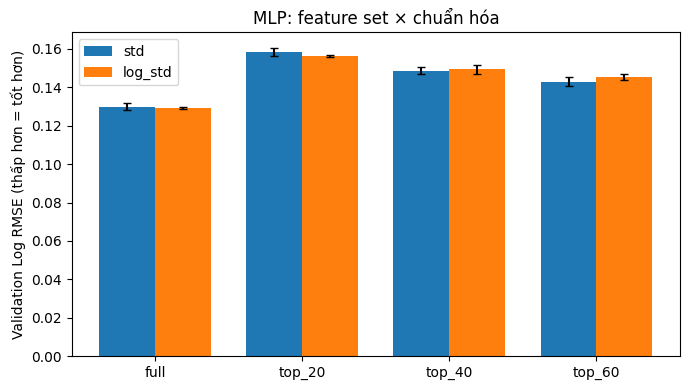

In [5]:
rowsA = []
for s in SETS:
    for mode in ["std", "log_std"]:
        r = multi_seed(data[s]["train"], y_train, data[s]["val"], y_val, DEFAULT_CFG, mode, SEEDS)
        rowsA.append(dict(feature_set=s, n_features=data[s]["train"].shape[1], transform=mode,
                          log_rmse_mean=r["mean"], log_rmse_std=r["std"], log_rmse_ens=r["ens"]))
        print(f"{s:7s} {mode:8s} feats={data[s]['train'].shape[1]:3d}  "
              f"{r['mean']:.5f} ± {r['std']:.5f}  (ens {r['ens']:.5f})")
dfA = pd.DataFrame(rowsA)
dfA.to_csv(OUT_DIR / "exp_A_feature_sets.csv", index=False)
bestA = dfA.sort_values("log_rmse_mean").iloc[0]
BEST_MODE = bestA["transform"]
print(f"\n=> Tốt nhất ở bước A: {bestA['feature_set']} + {BEST_MODE} ({bestA['log_rmse_mean']:.5f})")

fig, ax = plt.subplots(figsize=(7, 4))
w = 0.38
for i, mode in enumerate(["std", "log_std"]):
    sub = dfA[dfA["transform"] == mode]
    ax.bar(np.arange(len(SETS)) + (i - 0.5) * w, sub["log_rmse_mean"], w,
           yerr=sub["log_rmse_std"], capsize=3, label=mode)
ax.set_xticks(range(len(SETS)))
ax.set_xticklabels(SETS)
ax.set_ylabel("Validation Log RMSE (thấp hơn = tốt hơn)")
ax.set_title("MLP: feature set × chuẩn hóa")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_A_feature_sets.png", dpi=150)
plt.show()

## 5. Thực nghiệm A2 – Đặc trưng nâng cao

1. **Số lượng feature k:** xếp hạng Mutual Information trên train (đúng cách TV1 làm, `random_state=42`),
   thử thêm k = 80, 100, 150, 200 bên cạnh 20/40/60/279.
2. **Bỏ 7 feature TV1 tự tạo** (TotalSF, TotalBathrooms, …) khỏi tập Full để đo đóng góp của feature engineering.
3. **Loại outlier GrLivArea > 4000** khỏi tập train (paper De Cock khuyến nghị; val giữ nguyên để so sánh công bằng).

Kiểm tra: top-20 tính lại trùng 20/20 cột với Top20 của TV1
top- 20: 0.15640 ± 0.00073
top- 40: 0.15232 ± 0.00217
top- 60: 0.14594 ± 0.00250
top- 80: 0.14463 ± 0.00150
top-100: 0.14149 ± 0.00242
top-150: 0.14060 ± 0.00312
top-200: 0.13591 ± 0.00121
top-279: 0.12779 ± 0.00132
=> k tốt nhất: 279
Feature TV1 tự tạo tìm thấy: 7/7 | outlier GrLivArea>4000 trong train: 3

                            setting  log_rmse_mean  log_rmse_std  log_rmse_ens
                 Full (tham chiếu)        0.12911       0.00066       0.12585
         Full − feature TV1 tự tạo        0.13139       0.00137       0.12775
Full + loại outlier GrLivArea>4000        0.12821       0.00161       0.12485
            Top-279 + loại outlier        0.12707       0.00102       0.12367

Áp dụng loại outlier cho các bước sau: True


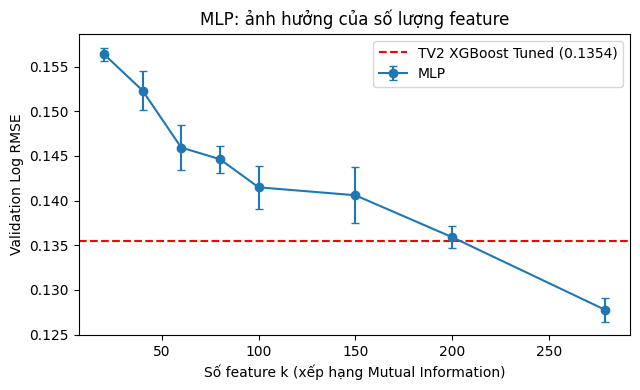

In [6]:
Xtr_full, Xva_full = data["full"]["train"], data["full"]["val"]
mi = mutual_info_regression(Xtr_full.values, np.log1p(y_train), random_state=RANDOM_STATE)
ranking = pd.Series(mi, index=Xtr_full.columns).sort_values(ascending=False)
ranking.rename("mutual_information").to_csv(OUT_DIR / "mi_ranking_recomputed.csv")
overlap = len(set(ranking.index[:20]) & set(data["top_20"]["train"].columns))
print(f"Kiểm tra: top-20 tính lại trùng {overlap}/20 cột với Top20 của TV1")

rowsK = []
for k in [20, 40, 60, 80, 100, 150, 200, Xtr_full.shape[1]]:
    cols = list(ranking.index[:k])
    r = multi_seed(Xtr_full[cols], y_train, Xva_full[cols], y_val, DEFAULT_CFG, BEST_MODE, SEEDS)
    rowsK.append(dict(k=k, log_rmse_mean=r["mean"], log_rmse_std=r["std"], log_rmse_ens=r["ens"]))
    print(f"top-{k:3d}: {r['mean']:.5f} ± {r['std']:.5f}")
dfK = pd.DataFrame(rowsK)
dfK.to_csv(OUT_DIR / "exp_A2_topk_curve.csv", index=False)
BEST_K = int(dfK.sort_values("log_rmse_mean").iloc[0]["k"])
BEST_COLS = list(ranking.index[:BEST_K])
BEST_LABEL = "Full" if BEST_K == Xtr_full.shape[1] else f"Top-{BEST_K}"
print(f"=> k tốt nhất: {BEST_K}")

ENGINEERED = ["TotalSF", "TotalBathrooms", "TotalPorchSF", "AgeAtSale", "RemodAge",
              "OverallQual_GrLivArea", "GarageCapacityArea"]
eng_present = [c for c in ENGINEERED if c in Xtr_full.columns]
keep_cols = [c for c in Xtr_full.columns if c not in eng_present]
keep_rows = (Xtr_full["GrLivArea"] <= 4000).values
print(f"Feature TV1 tự tạo tìm thấy: {len(eng_present)}/{len(ENGINEERED)} | outlier GrLivArea>4000 trong train: {int((~keep_rows).sum())}")

abl = {}
abl["Full (tham chiếu)"] = multi_seed(Xtr_full, y_train, Xva_full, y_val, DEFAULT_CFG, BEST_MODE, SEEDS)
abl["Full − feature TV1 tự tạo"] = multi_seed(Xtr_full[keep_cols], y_train, Xva_full[keep_cols], y_val,
                                              DEFAULT_CFG, BEST_MODE, SEEDS)
abl["Full + loại outlier GrLivArea>4000"] = multi_seed(Xtr_full[keep_rows], y_train[keep_rows], Xva_full, y_val,
                                                       DEFAULT_CFG, BEST_MODE, SEEDS)
abl[f"Top-{BEST_K} + loại outlier"] = multi_seed(Xtr_full.loc[keep_rows, BEST_COLS], y_train[keep_rows],
                                                 Xva_full[BEST_COLS], y_val, DEFAULT_CFG, BEST_MODE, SEEDS)
dfAbl = pd.DataFrame([dict(setting=k, log_rmse_mean=v["mean"], log_rmse_std=v["std"], log_rmse_ens=v["ens"])
                      for k, v in abl.items()])
dfAbl.to_csv(OUT_DIR / "exp_A2_ablation.csv", index=False)
print("\n", dfAbl.round(5).to_string(index=False))

# Quyết định loại outlier: chỉ áp dụng nếu thật sự cải thiện so với cùng tập feature
DROP_OUTLIERS = abl["Full + loại outlier GrLivArea>4000"]["mean"] < abl["Full (tham chiếu)"]["mean"]
print(f"\nÁp dụng loại outlier cho các bước sau: {DROP_OUTLIERS}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.errorbar(dfK["k"], dfK["log_rmse_mean"], yerr=dfK["log_rmse_std"], marker="o", capsize=3, label="MLP")
ax.axhline(TV2_XGB_TUNED, color="red", ls="--", label="TV2 XGBoost Tuned (0.1354)")
ax.set_xlabel("Số feature k (xếp hạng Mutual Information)")
ax.set_ylabel("Validation Log RMSE")
ax.set_title("MLP: ảnh hưởng của số lượng feature")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_A2_topk_curve.png", dpi=150)
plt.show()

## 6. Thực nghiệm B – Tìm hyperparameter

Random search trên lưới nhỏ, **chọn bằng 3-fold CV chỉ trên tập train** (val không dùng để chọn),
trên feature set tốt nhất ở bước A2. Sau đó đo các cấu hình top-3 trên val để báo cáo.

In [7]:
GRID = dict(hidden=[(128,), (256, 128), (512, 256, 128), (256, 256)],
            dropout=[0.1, 0.2, 0.3], lr=[3e-4, 1e-3, 3e-3], batch=[32, 64],
            wd=[1e-4, 1e-3, 1e-2], optimizer=["adam", "adamw"])
rng = random.Random(RANDOM_STATE)
configs = [dict(DEFAULT_CFG)] + [dict({k: rng.choice(v) for k, v in GRID.items()}, epochs=EPOCHS)
                                 for _ in range(N_CONFIGS - 1)]

if DROP_OUTLIERS:
    Xtr_sel, ytr_sel = Xtr_full.loc[keep_rows, BEST_COLS].reset_index(drop=True), y_train[keep_rows]
else:
    Xtr_sel, ytr_sel = Xtr_full[BEST_COLS], y_train
Xva_sel = Xva_full[BEST_COLS]

rowsB = []
for i, cfg in enumerate(configs):
    cv = cv_score(Xtr_sel, ytr_sel, cfg, BEST_MODE)
    rowsB.append(dict(config_id=i, hidden=str(cfg["hidden"]), dropout=cfg["dropout"], lr=cfg["lr"],
                      batch=cfg["batch"], weight_decay=cfg["wd"], optimizer=cfg["optimizer"], cv_log_rmse=cv))
    print(f"[{i:2d}] {cfg['hidden']!s:16s} drop={cfg['dropout']} lr={cfg['lr']:<6} bs={cfg['batch']} "
          f"wd={cfg['wd']:<6} {cfg['optimizer']:6s} CV={cv:.5f}")
dfB = pd.DataFrame(rowsB).sort_values("cv_log_rmse").reset_index(drop=True)

top3 = []
for _, row in dfB.head(3).iterrows():
    r = multi_seed(Xtr_sel, ytr_sel, Xva_sel, y_val, configs[int(row["config_id"])], BEST_MODE, SEEDS)
    top3.append(r["mean"])
dfB["val_log_rmse_top3"] = top3 + [np.nan] * (len(dfB) - len(top3))
dfB.to_csv(OUT_DIR / "exp_B_hyperparams.csv", index=False)
print("\n", dfB.round(5).to_string(index=False))
BEST_CFG = configs[int(dfB.iloc[0]["config_id"])]
print("\n=> Cấu hình được chọn (theo CV trên train):", BEST_CFG)

[ 0] (256, 128)       drop=0.2 lr=0.001  bs=32 wd=0.001  adamw  CV=0.12304
[ 1] (128,)           drop=0.1 lr=0.003  bs=64 wd=0.0001 adam   CV=0.12537
[ 2] (256, 128)       drop=0.3 lr=0.0003 bs=32 wd=0.01   adamw  CV=0.11657
[ 3] (128,)           drop=0.1 lr=0.0003 bs=32 wd=0.0001 adam   CV=0.13197
[ 4] (256, 128)       drop=0.3 lr=0.003  bs=64 wd=0.0001 adamw  CV=0.12416
[ 5] (512, 256, 128)  drop=0.1 lr=0.0003 bs=64 wd=0.001  adamw  CV=0.12758
[ 6] (256, 128)       drop=0.1 lr=0.001  bs=32 wd=0.0001 adamw  CV=0.12568
[ 7] (128,)           drop=0.2 lr=0.001  bs=64 wd=0.0001 adamw  CV=0.12311
[ 8] (128,)           drop=0.2 lr=0.0003 bs=64 wd=0.01   adamw  CV=0.13033
[ 9] (256, 128)       drop=0.3 lr=0.0003 bs=32 wd=0.01   adam   CV=0.13053
[10] (512, 256, 128)  drop=0.1 lr=0.0003 bs=32 wd=0.001  adamw  CV=0.12565
[11] (256, 256)       drop=0.3 lr=0.001  bs=32 wd=0.001  adamw  CV=0.12383

  config_id          hidden  dropout     lr  batch  weight_decay optimizer  cv_log_rmse  val_log_rm

## 7. Đánh giá cuối trên validation và so sánh với TV2

MLP tốt nhất: Log RMSE = 0.127571 ± 0.002666 (trung bình 10 seed)
Ensemble 10 seed (trung bình dự đoán): 0.123777


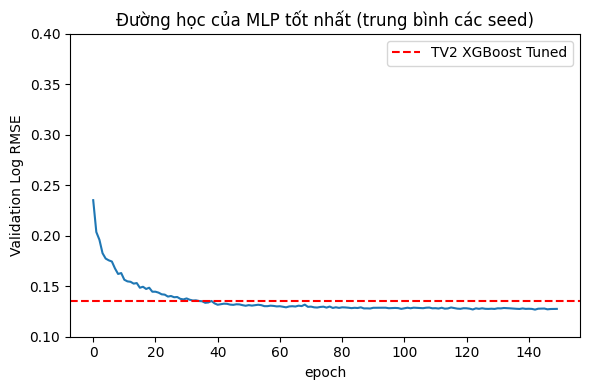


                    Model Feature_Set  Log_RMSE
  MLP (ensemble 10 seed)        Full  0.123777
MLP (1 seed, trung bình)        Full  0.127571
           XGBoost Tuned        Full  0.135426
        XGBoost Baseline        Full  0.137608
           Random Forest        Full  0.151819


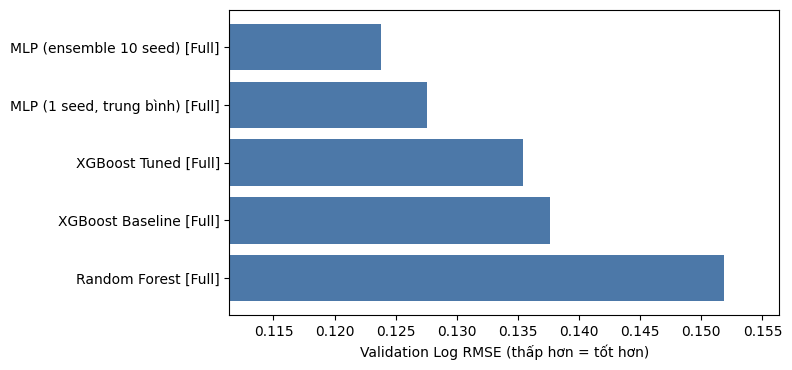


MLP VƯỢT XGBoost Tuned của TV2 (chênh -0.007855).


In [8]:
final = multi_seed(Xtr_sel, ytr_sel, Xva_sel, y_val, BEST_CFG, BEST_MODE, list(range(N_FINAL_SEEDS)))
print(f"MLP tốt nhất: Log RMSE = {final['mean']:.6f} ± {final['std']:.6f} (trung bình {N_FINAL_SEEDS} seed)")
print(f"Ensemble {N_FINAL_SEEDS} seed (trung bình dự đoán): {final['ens']:.6f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(final["hist"])
ax.axhline(TV2_XGB_TUNED, color="red", ls="--", label="TV2 XGBoost Tuned")
ax.set_ylim(0.1, 0.4)
ax.set_xlabel("epoch")
ax.set_ylabel("Validation Log RMSE")
ax.set_title("Đường học của MLP tốt nhất (trung bình các seed)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_C_learning_curve.png", dpi=150)
plt.show()

compare = pd.DataFrame([
    dict(Model="Random Forest", Feature_Set="Full", Log_RMSE=0.151819),
    dict(Model="XGBoost Baseline", Feature_Set="Full", Log_RMSE=0.137608),
    dict(Model="XGBoost Tuned", Feature_Set="Full", Log_RMSE=TV2_XGB_TUNED),
    dict(Model="MLP (1 seed, trung bình)", Feature_Set=BEST_LABEL, Log_RMSE=final["mean"]),
    dict(Model=f"MLP (ensemble {N_FINAL_SEEDS} seed)", Feature_Set=BEST_LABEL, Log_RMSE=final["ens"]),
]).sort_values("Log_RMSE").reset_index(drop=True)
compare.to_csv(OUT_DIR / "comparison_with_tv2.csv", index=False)
print("\n", compare.round(6).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh(compare["Model"] + " [" + compare["Feature_Set"] + "]", compare["Log_RMSE"], color="#4C78A8")
ax.invert_yaxis()
ax.set_xlim(compare["Log_RMSE"].min() * 0.9, compare["Log_RMSE"].max() * 1.03)
ax.set_xlabel("Validation Log RMSE (thấp hơn = tốt hơn)")
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_C_comparison.png", dpi=150)
plt.show()

beats = final["mean"] < TV2_XGB_TUNED
print(f"\nMLP {'VƯỢT' if beats else 'KHÔNG vượt'} XGBoost Tuned của TV2 "
      f"(chênh {final['mean'] - TV2_XGB_TUNED:+.6f}).")

## 8. Train lại trên Train + Validation và tạo submission (giống cách TV2 làm)

Số epoch cố định nên không rò rỉ thông tin từ val. Ensemble nhiều seed để dự đoán ổn định.

In [9]:
X_all = pd.concat([Xtr_full[BEST_COLS], Xva_full[BEST_COLS]], axis=0, ignore_index=True)
y_all = np.concatenate([y_train, y_val])
if DROP_OUTLIERS:
    mask_all = (pd.concat([Xtr_full["GrLivArea"], Xva_full["GrLivArea"]], ignore_index=True) <= 4000).values
    X_all, y_all = X_all[mask_all].reset_index(drop=True), y_all[mask_all]
X_test = data["full"]["test"][BEST_COLS]

Xa, Xt_ = transform_features(X_all, [X_test], BEST_MODE)
test_preds = []
for s in range(N_FINAL_SEEDS):
    (p,), _ = train_mlp(Xa, np.log1p(y_all), BEST_CFG, s, [Xt_], None)
    test_preds.append(p)
test_pred = np.maximum(np.expm1(np.mean(test_preds, axis=0)), 0)

submission = pd.DataFrame({"Id": test_ids["Id"], "SalePrice": test_pred})
submission.to_csv(OUT_DIR / "submission_mlp.csv", index=False)
print("Train rows:", len(X_all), "| Test rows:", len(X_test), "| NaN:", int(submission.isna().sum().sum()))
print(f"SalePrice min={submission['SalePrice'].min():.0f} max={submission['SalePrice'].max():.0f}")
print(submission.head())

Train rows: 1456 | Test rows: 1459 | NaN: 0
SalePrice min=34973 max=1033502
     Id      SalePrice
0  1461  126602.031250
1  1462  155920.734375
2  1463  182991.218750
3  1464  200058.546875
4  1465  181767.796875


## 9. Tổng kết (bàn giao cho nhóm)

In [10]:
summary = dict(
    best_mlp=dict(feature_set=f"{BEST_LABEL} (Mutual Information)", n_features=BEST_K,
                  transform=BEST_MODE, drop_outliers_GrLivArea_gt_4000=bool(DROP_OUTLIERS),
                  architecture=list(BEST_CFG["hidden"]), learning_rate=BEST_CFG["lr"],
                  batch_size=BEST_CFG["batch"], dropout=BEST_CFG["dropout"],
                  weight_decay=BEST_CFG["wd"], epochs=BEST_CFG["epochs"], optimizer=BEST_CFG["optimizer"]),
    validation_log_rmse_mean=final["mean"], validation_log_rmse_std=final["std"],
    validation_log_rmse_ensemble=final["ens"], n_seeds=N_FINAL_SEEDS,
    tv2_xgboost_tuned_val=TV2_XGB_TUNED, mlp_beats_xgboost_tuned=bool(beats),
    note="Kaggle score của submission_mlp.csv: điền thủ công sau khi submit.",
)
(OUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("Best MLP:")
for k, v in summary["best_mlp"].items():
    print(f"  {k}: {v}")
print(f"  Validation Log RMSE: {final['mean']:.6f} ± {final['std']:.6f} (ensemble {final['ens']:.6f})")
print("\nFile kết quả trong:", OUT_DIR.resolve())

Best MLP:
  feature_set: Full (Mutual Information)
  n_features: 279
  transform: log_std
  drop_outliers_GrLivArea_gt_4000: True
  architecture: [256, 128]
  learning_rate: 0.0003
  batch_size: 32
  dropout: 0.3
  weight_decay: 0.01
  epochs: 150
  optimizer: adamw
  Validation Log RMSE: 0.127571 ± 0.002666 (ensemble 0.123777)

File kết quả trong: C:\Users\GIA NGUYEN\Desktop\SGU26K2_HocSau_S5_DCT123C4_Nhom666HocSau\lab03_house_price_Ly Hong Hung_3123411132\HousePrices_TV3\results\member3
